# Question 2: Testing

## Assignment
> Marktplaats has decided on implementing a product feature that we think
will drive the number of Car ads with leads: How would you ideally set up the test
whether this initiative has improved this metric?
> - Why do you choose this method?
> - What are the risks / challenges?
> - Use the dataset attached to examine the test groups:
>   - What is the result of your analysis?
>   - What insights did you gain?

## 1. Business Question and Test Design


### Primary KPI
Share of Car Ads With at Least One Lead.

`has_any_lead = telclicks > 0 OR bids > 0 OR n_asq > 0 OR webclicks > 0`

### Test Design
Use a randomized A/B test to answer whether the new product feature increases the share of car ads that receive at least one lead.

Why this method:

- Random assignment is the cleanest way to estimate whether the feature caused a change in lead rate.
- It makes treatment and control ads more comparable before exposure.
- It is better than a before/after comparison, which can be affected by seasonality, buyer demand, or changes in ad supply.

Preferred randomization level: ad-level, assuming the feature affects individual ads and does not strongly change seller behavior across ads. If the feature is seller-side, seller-level randomization may be safer.

### Design Risks to Control Upfront

Before treating any observed difference as causal, the test design should address:

- Group assignment: confirm which group is treatment. The data shows B has higher leads, but it does not prove B is the treatment group.
- Randomization quality: groups should be balanced on key ad/car dimensions.
- Sample-ratio monitoring: observed group sizes should match the planned allocation within expected noise.
- Pre-defined exclusions: missing or invalid assignment rows should be handled by rules set before reading outcomes.
- Interference: treated ads may take leads from similar control ads.
- Logging quality: lead events should be tracked the same way in A and B.
- Guardrails: monitor lead quality, duplicate leads, seller quality, and buyer complaints.

In [1]:
from pathlib import Path
import sys
import importlib

import pandas as pd
from IPython.display import display

helper_dir = Path.cwd()
if not (helper_dir / "functions.py").exists():
    helper_dir = Path.cwd() / "assignments" / "data_analyst"
if str(helper_dir) not in sys.path:
    sys.path.insert(0, str(helper_dir))

import functions as helpers

helpers = importlib.reload(helpers)

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 80)
helpers.plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
# Plotting utilities live in functions.py so chart styling stays consistent.


## 2. Data Quality Checks

Before comparing A and B, the dataset needs to pass a few basic quality checks: how many rows are available, how many can be assigned to the A/B comparison, whether lead metrics are consistently logged, and whether duplicate IDs could distort the result.

In [3]:
raw_data = helpers.read_ab_test_data(helpers.DATA_PATH)
ab_data, excluded_data = helpers.prepare_ab_data(raw_data)
segmented_data = helpers.add_segments(ab_data)

print(f"Rows: {len(raw_data):,}")
print(f"A/B-assigned rows: {len(ab_data):,}")
print(f"Rows dropped for missing group: {len(excluded_data):,} ({len(excluded_data) / len(raw_data):.2%})")

display(helpers.style_table(helpers.data_quality_checks(raw_data)))
display(helpers.style_table(helpers.undocumented_column_notes(raw_data)))
display(helpers.style_table(helpers.excluded_group_summary(raw_data, excluded_data)))
display(helpers.style_table(helpers.lead_metric_quality(raw_data)))

Rows: 183,062
A/B-assigned rows: 174,449
Rows dropped for missing group: 8,613 (4.70%)


,Check,Value
0,Rows,"183,062"
1,Columns,22
2,Fully Duplicated Rows,0
3,Rows With Duplicated Ad ID,10
4,Unique Ad IDs,"183,057"


,Column,Note
0,Color,used as an optional car-color dimension
1,Mileage,used as an optional mileage dimension
2,Days Live,used as an optional ad-tenure dimension
3,L2,not used; meaning is unclear


,Metric,Rows,Row Share
0,Raw Rows,"183,062",1.000
1,Valid A/B Rows,"174,449",0.953
2,Missing-Group Rows,"8,613",0.047


,Metric,Missing Rows,Missing %,Negative Rows,Zero Rows,Max Value
0,Tel Clicks,9,0.000,0,"125,624",162
1,Bids,9,0.000,0,"152,145",124
2,Questions,0,0.000,0,"122,577",282
3,Web Clicks,9,0.000,0,"85,122",410


In [4]:
display(helpers.style_table(helpers.column_quality_summary(raw_data).query("missing_rows > 0"), max_rows=12))

,Column,Dtype,Missing Rows,Missing %,Unique
0,Energy Label,str,"49,384",0.270,7
1,Body Type,str,"17,851",0.098,8
2,Seats,Int64,"11,743",0.064,16
3,Test Group,str,"8,613",0.047,2
4,Doors,Int64,"5,375",0.029,9
5,Model,str,925,0.005,"2,447"
6,Emissions,Int64,191,0.001,356
7,Bids,Int64,9,0.000,42
8,Tel Clicks,Int64,9,0.000,65
9,Web Clicks,Int64,9,0.000,154


The first question is how much of the raw dataset can actually be used for the A/B comparison. Rows without a valid `group` value are excluded from outcome comparisons because they cannot be assigned to either A or B.

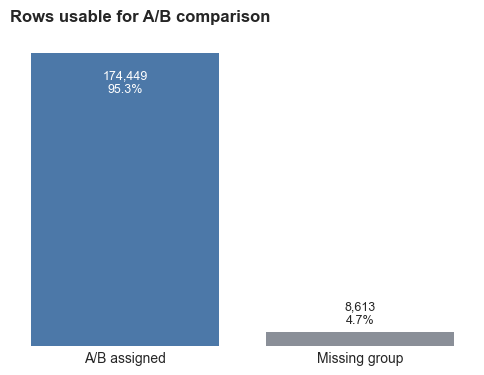

In [5]:
helpers.plot_row_coverage(raw_data, ab_data, excluded_data)
helpers.plt.show()


Most rows can be used for the A/B analysis: 95.3% have an A/B assignment. The 4.7% missing-group rows are not large enough to stop the analysis, but they should be investigated because exclusion rules should be defined before reading outcomes.

Next, check the lead-event fields. Missing value and negative value checks are best kept in the table above, while the chart below shows how often each lead channel has any activity.

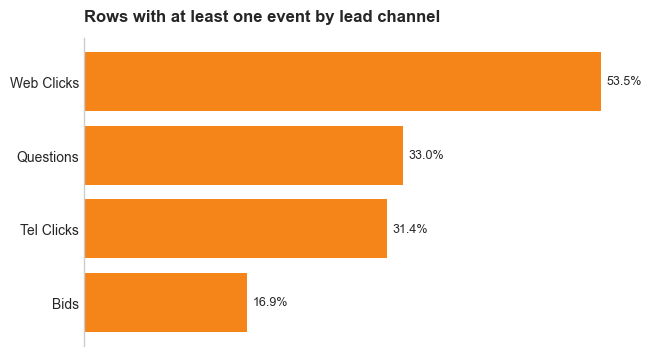

In [6]:
helpers.plot_lead_channel_coverage(raw_data)
helpers.plt.show()


Individual lead channels have relatively few non-zero rows, especially compared with the combined "any lead" KPI used later. This supports the primary metric choice: combining `telclicks`, `bids`, `n_asq`, and `webclicks` captures whether an ad generated any buyer interest, while later lead-volume checks still show how the channels contribute separately.

The remaining field checks show very few missing values in the lead metrics and no negative lead values. Some undocumented fields are useful as car/ad dimensions for balance and segmentation checks; `l2` is excluded because its meaning is unclear.

### Duplicated Ad IDs

There are 5 duplicated `src_ad_id` values, covering 10 rows. This is a data-quality issue, so inspect it before deciding how to handle these rows.

In [7]:
display(helpers.style_table(helpers.duplicated_ad_id_rows(raw_data)))

,Ad ID,Tel Clicks,Bids,Body Type,Photos,Doors,Questions,Build Year,Emissions,Energy Label,Brand,Start Date,Power,Web Clicks,Model,Seats,Price,Test Group
0,1011548826,0,0,MPV,18,5,0,2003,152,D,RENAULT,2016-11-25,59,1,Scenic,5,"22,500",A
1,1011548826,0,0,Hatchback (3/5-deurs),14,4,0,2005,169,C,CITROEN,2016-11-25,80,0,C4,5,"52,500",B
2,1027581466,0,0,Hatchback (3/5-deurs),13,5,0,2010,0,NaN,SEAT,2016-11-06,118,2,Leon,5,"117,500",A
3,1027581466,0,0,MPV,24,4,0,2008,155,C,MERCEDES,2016-11-06,70,0,A-Klasse,5,"79,500",B
4,1045227572,0,0,Hatchback (3/5-deurs),24,5,0,2012,134,C,OPEL,2016-11-26,74,0,CORSA,5,"89,500",A
5,1045227572,0,0,Terreinwagen,24,5,0,2013,168,D,MINI,2016-11-26,90,1,Countryman,5,"269,500",B
6,1054003502,0,0,Stationwagon,24,5,0,2005,235,F,SAAB,2016-11-19,154,2,3-Sep,5,"64,000",A
7,1054003502,1,0,Sedan (2/4-deurs),11,4,0,2006,186,C,AUDI,2016-11-19,103,2,A6,5,"73,900",A
8,1072325510,0,0,Hatchback (3/5-deurs),12,3,0,2013,92,A,FIAT,2016-11-07,63,0,500,4,"99,450",A
9,1072325510,0,0,Cabriolet,24,2,0,2000,294,NaN,CHEVROLET,2016-11-07,142,3,Camaro,4,"119,000",B


In [8]:
display(helpers.style_table(helpers.duplicated_ad_id_differences(raw_data)))

,Ad ID,Rows,Groups Seen,Varying Columns
0,1011548826,2,"A, B","carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"
1,1027581466,2,"A, B","carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"
2,1045227572,2,"A, B","carrosserie, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"
3,1054003502,2,A,"telclicks, carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, model, price"
4,1072325510,2,"A, B","carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"


The paired duplicate-ID rows differ on car attributes. I keep them in the primary analysis because they are only 10 rows, then test sensitivity later by excluding them.

## 3. Group Assignment Check

TL;DR: B has fewer records than A among A/B-assigned rows. This mainly reduces statistical power and should trigger a sample ratio check; it is not direct evidence that the groups differ in composition.

In [9]:
display(helpers.style_table(helpers.group_size_summary(ab_data)))

,Test Group,Rows,Row Share
0,A,"94,281",0.540
1,B,"80,168",0.460


B has fewer records than A. By itself, this does not imply the groups differ in composition; it mostly reduces statistical power because the smaller group limits precision. The practical implication is to run a sample ratio mismatch check and review whether assignment or exclusions created the uneven split.

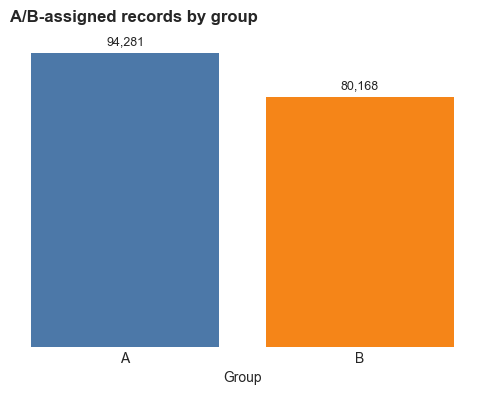

In [10]:
helpers.plot_group_sizes(ab_data)
helpers.plt.show()


B has about 80k assigned records versus 94k in A. This mainly affects precision: the smaller B group gives the test slightly less statistical power, but it does not by itself show that the groups differ in composition.

## 4. Balance Check: Are A and B Comparable?

TL;DR: B records differ from A on key car/ad dimensions such as price, mileage, and age. This is the more important concern for causal interpretation because it may mean the groups are not comparable.

In [11]:
display(helpers.style_table(helpers.numeric_balance_summary(ab_data)))

group,Dimension,A,B,Diff B-A,% Diff
0,Price,"106,457.104","95,563.256","-10,893.849",-0.102
1,Mileage,"140,764.544","149,516.859","8,752.315",0.062
2,Days Live,27.624,27.646,0.022,0.001
3,Photos,15.742,15.366,-0.376,-0.024
4,Build Year,2007.560,2006.721,-0.839,-0.000
5,Doors,4.270,4.220,-0.049,-0.012
6,Seats,4.735,4.747,0.012,0.002
7,Emissions,129.123,129.950,0.827,0.006
8,Power,85.787,85.420,-0.367,-0.004
9,Car Age,8.440,9.279,0.839,0.099


B differs from A on several car/ad dimensions, especially price, mileage, and car age. Unlike the record-count imbalance, this affects group comparability. If these differences came from imperfect randomization, filtering, or exposure rules, part of the lead-rate difference could reflect group composition rather than the feature itself. This should be accounted for in test design, ideally before launch.

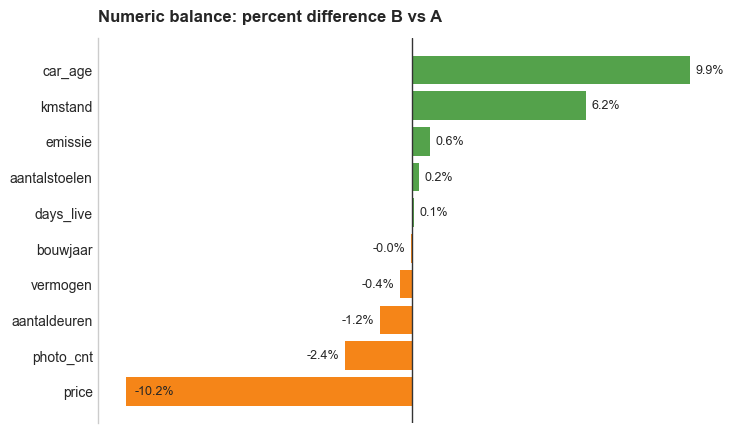

In [12]:
helpers.plot_numeric_balance(ab_data)
helpers.plt.show()


The largest balance gaps are price, car age, and mileage: B cars are about 10% cheaper, 10% older, and 6% higher mileage on average. These differences matter because they could affect lead rates even without a product change.

## 5. Primary Result: Did B Increase Ads With Leads?

TL;DR: B's lead rate is 74.8% versus 72.8% for A, a statistically significant difference of about 2.0 percentage points (p < 0.001, using a 5% significance level). The causal interpretation still depends on the assignment and balance checks above. We should not assume B is treatment unless the experiment setup confirms it.


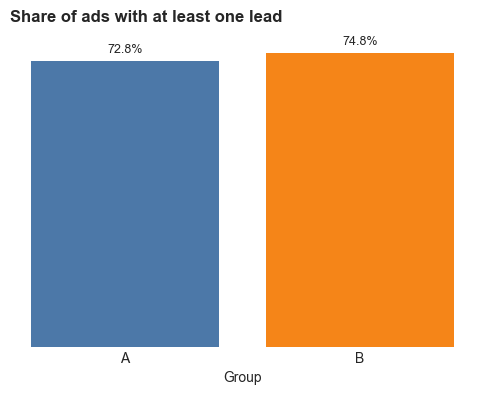

In [13]:
outcomes = helpers.lead_outcome_summary(ab_data)

helpers.plot_lead_rate(outcomes)
helpers.plt.show()


This chart shows the primary KPI directly, so the group lead rates do not need to be repeated in a table here. The compact summary below focuses only on the lift and statistical readout. Here, absolute lead-rate lift means B lead rate minus A lead rate, measured in percentage points. Relative lift means that same difference divided by A's lead rate.


In [14]:
display(helpers.lift_summary_table(ab_data).style.hide(axis="index"))


Metric,Value
Absolute lead-rate lift,2.0 pp
95% CI for absolute lift,1.6 to 2.4 pp
Relative lift vs A,2.8%
p-value,<0.001
Significance level,5%
Approx. power for observed effect,>99.9%


The lift table keeps the statistical readout separate from the visual KPI comparison.

Key terms:

- Absolute lift: how many more ads got at least one lead in B than in A, shown in percentage points.
- Relative lift: the same improvement compared with A's starting level.
- Significance level: how strict we are before treating the observed gap as unlikely to be random noise.
- Statistical power: how likely the test is to catch an effect if an effect is really there.


## 6. Lead Volume Checks: Is the Result Broader Than the Yes/No Lead Metric?

TL;DR: B also has higher average lead volume per ad. These checks show whether the result extends beyond the yes/no lead metric and whether averages are dominated by a few very high-lead ads.

B is higher not only on the binary lead-rate KPI, but also on average lead volume. The channel split shows where that higher volume comes from and checks whether the total-leads improvement is concentrated in a single lead type.

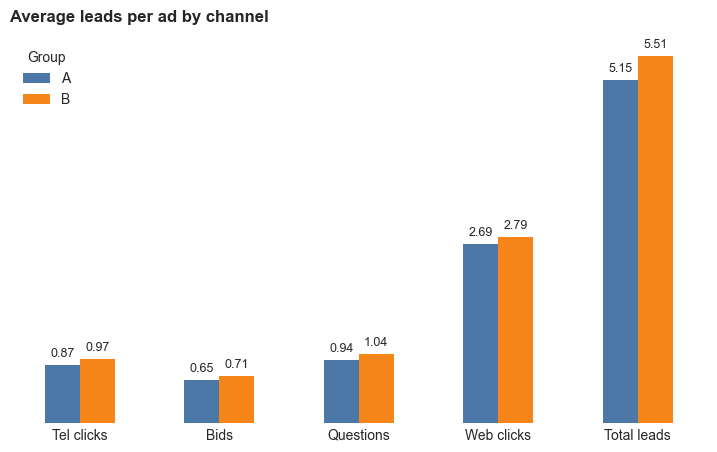

In [15]:
helpers.plot_average_leads_by_channel(outcomes)
helpers.plt.show()


B is higher on every lead channel and on total leads per ad. The improvement is not isolated to one channel, although the absolute gaps by channel are small.

This distribution is a supporting check, not the primary result. It shows whether B's higher average total leads is visible across the common range of ads or mainly caused by a small number of extreme high-lead ads. The distribution is very skewed, so values are capped at p99 and A/B are shown in separate panels with the same scale.

,Metric,Value
0,Count,"174,449"
1,Mean,5.316
2,Std,9.228
3,Min,0
4,25%,0
5,50%,2
6,75%,7
7,90%,14
8,95%,20
9,99%,40


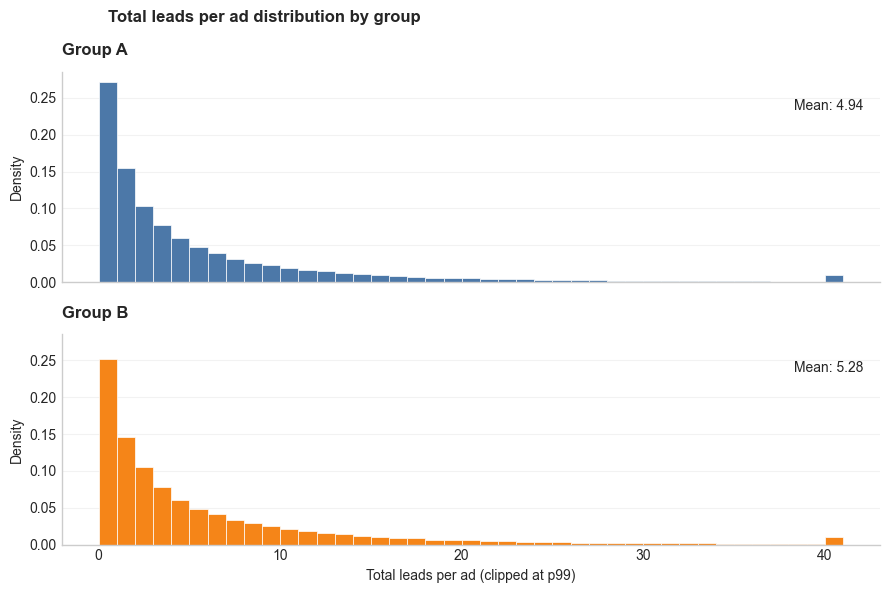

In [16]:
display(helpers.style_table(helpers.lead_distribution_summary(ab_data)))

helpers.plot_total_leads_distribution(ab_data)
helpers.plt.show()


Both groups have a strongly right-skewed lead distribution: many ads receive few leads, while a small number receive many. B has a higher mean, but the common range looks broadly similar, so the binary lead-rate result remains the cleaner primary readout.

## 7. Robustness Check: Do Duplicate Ad IDs Change the Result?

Purpose: verify that the duplicate-ID issue found during data readiness does not drive the primary conclusion.

In [17]:
display(helpers.style_table(helpers.duplicate_id_sensitivity(ab_data)))

,Metric,With Dup IDs,Excl Dup IDs
0,Rows,"174,449","174,439"
1,Rows Dropped,0,10
2,% Rows Dropped,0,0.000
3,A Lead Rate,0.728,0.728
4,B Lead Rate,0.748,0.748
5,Abs Lead-Rate Lift,0.020,0.020
6,Relative Lift vs A,0.028,0.028


Excluding duplicated `src_ad_id` rows does not materially change the A/B lead-rate comparison. The result is robust to this specific data-quality issue.

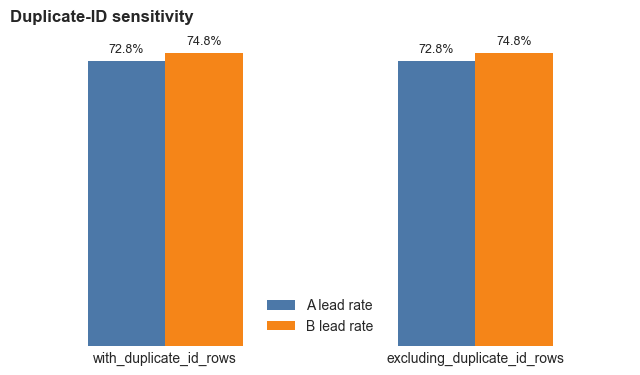

In [18]:
helpers.plot_duplicate_id_sensitivity(ab_data)
helpers.plt.show()


Removing duplicated ad IDs leaves the A and B lead rates essentially unchanged. The duplicate-ID issue is worth documenting, but it does not drive the main result.

## 8. Segment Checks: Where Is the Lift Stronger or Weaker?

Segment cuts are exploratory only. Price and mileage use fixed, rounded bands for readability rather than quartile-based cutoffs. Lead rate means the share of ads with at least one lead. In this section, lift also means the absolute B minus A lead-rate difference, shown in percentage points. Dropped rows are rows that cannot be assigned to a band, usually because the source value is missing.


In [19]:
segment_columns = ["price_band", "km_band", "car_age_band"]
display(helpers.style_table(helpers.segment_coverage_summary(segmented_data, segment_columns)))
display(helpers.style_table(helpers.segment_outcome_summary(segmented_data, "price_band")))
display(helpers.style_table(helpers.segment_outcome_summary(segmented_data, "km_band")))
display(helpers.style_table(helpers.segment_outcome_summary(segmented_data, "car_age_band")))
display(helpers.style_table(helpers.top_category_segment_summary(ab_data, "brand")))

,Segment,Source Column,Rows Used,Rows Dropped,Missing Source,Out of Band,% Rows Dropped
0,Price Band,Price,"174,443",6,6,0,0.000
1,Mileage Band,Mileage,"173,112","1,337","1,337",0,0.008
2,Car Age Band,Car Age,"174,449",0,0,0,0.000


,Price Band,Ad Count A,Ad Count B,Lead Rate A,Lead Rate B,Avg Leads/Ad A,Avg Leads/Ad B,Abs Lift,Rel Lift,Small Segment
0,0-25k,"25,086","24,742",0.884,0.886,8.702,8.672,0.001,0.001,False
1,25k-60k,"21,301","18,979",0.797,0.801,5.751,5.837,0.004,0.006,False
2,60k-120k,"23,041","18,188",0.660,0.669,3.451,3.608,0.009,0.013,False
3,120k+,"24,849","18,257",0.575,0.587,2.627,2.780,0.012,0.021,False


,Mileage Band,Ad Count A,Ad Count B,Lead Rate A,Lead Rate B,Avg Leads/Ad A,Avg Leads/Ad B,Abs Lift,Rel Lift,Small Segment
0,0-75k,"24,222","17,899",0.517,0.532,2.447,2.621,0.015,0.029,False
1,75k-150k,"29,490","24,272",0.744,0.751,5.001,5.240,0.007,0.010,False
2,150k-200k,"17,814","16,325",0.821,0.829,6.451,6.699,0.008,0.009,False
3,200k+,"22,067","21,023",0.858,0.862,7.098,7.229,0.004,0.005,False


,Car Age Band,Ad Count A,Ad Count B,Lead Rate A,Lead Rate B,Avg Leads/Ad A,Avg Leads/Ad B,Abs Lift,Rel Lift,Small Segment
0,0-3,"19,307","13,345",0.472,0.466,1.808,1.696,-0.006,-0.012,False
1,4-7,"24,682","19,036",0.693,0.695,3.887,3.962,0.002,0.003,False
2,8-12,"26,590","23,446",0.813,0.818,6.160,6.186,0.005,0.007,False
3,13+,"23,702","24,341",0.878,0.877,8.056,8.160,-0.001,-0.001,False


,Brand,Ad Count A,Ad Count B,Lead Rate A,Lead Rate B,Avg Leads/Ad A,Avg Leads/Ad B,Abs Lift,Rel Lift,Small Segment
0,BMW,"4,804","4,011",0.790,0.815,6.747,7.111,0.025,0.031,False
1,CITROEN,"4,432","3,670",0.671,0.684,4.030,4.263,0.013,0.020,False
2,FORD,"6,964","5,720",0.660,0.679,4.163,4.402,0.019,0.029,False
3,MERCEDES,"3,965","3,492",0.782,0.814,6.337,6.701,0.032,0.041,False
4,OPEL,"7,674","6,673",0.735,0.750,5.219,5.450,0.015,0.020,False
5,PEUGEOT,"7,967","6,847",0.632,0.659,4.130,4.521,0.027,0.042,False
6,RENAULT,"7,717","6,590",0.695,0.723,4.150,4.743,0.028,0.040,False
7,VOLKSWAGEN,"11,464","9,632",0.797,0.811,6.671,7.057,0.014,0.017,False


B is higher across price and mileage bands, car-age results are mixed, and most top brands show positive lift. These are pattern checks, not subgroup causal claims.

The tables above give the exact segment values. The plots below separate each segment view so the pattern is easier to read.

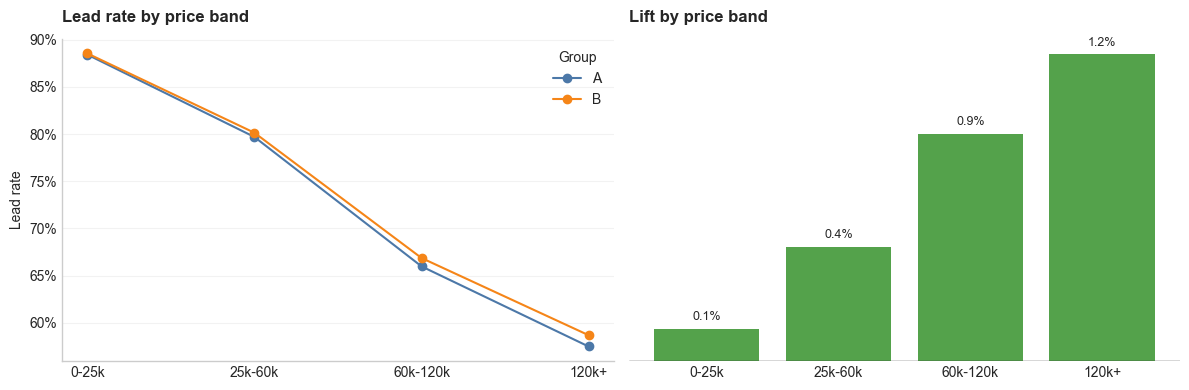

In [20]:
helpers.plot_segment_lift(segmented_data, "price_band", "Lead rate by price band", "Lift by price band")
helpers.plt.show()


Price-band lift is positive in every band and increases with price. The biggest lift is in the `120k+` band, which suggests B's advantage is strongest among higher-priced cars.

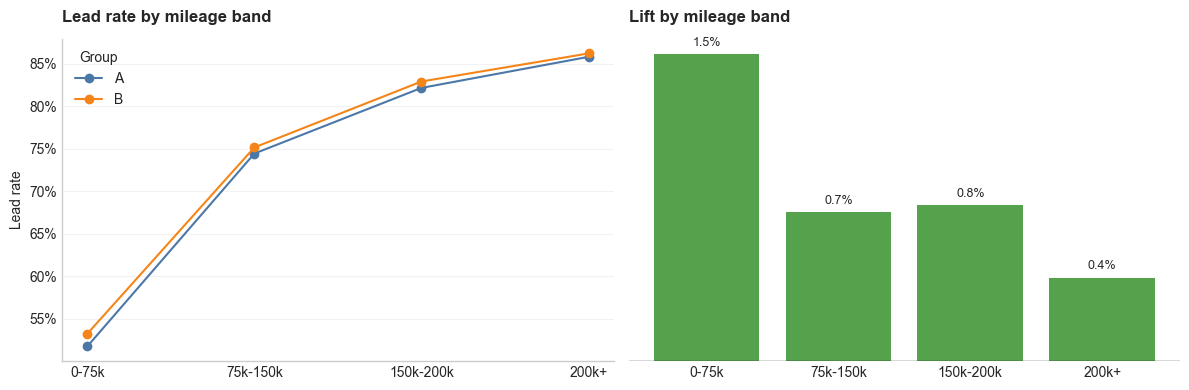

In [21]:
helpers.plot_segment_lift(segmented_data, "km_band", "Lead rate by mileage band", "Lift by mileage band")
helpers.plt.show()


Mileage-band lift is positive in every band, with the strongest lift in the `0-75k` band. The lift is smaller for higher-mileage cars, so B's advantage appears strongest among lower-mileage listings.

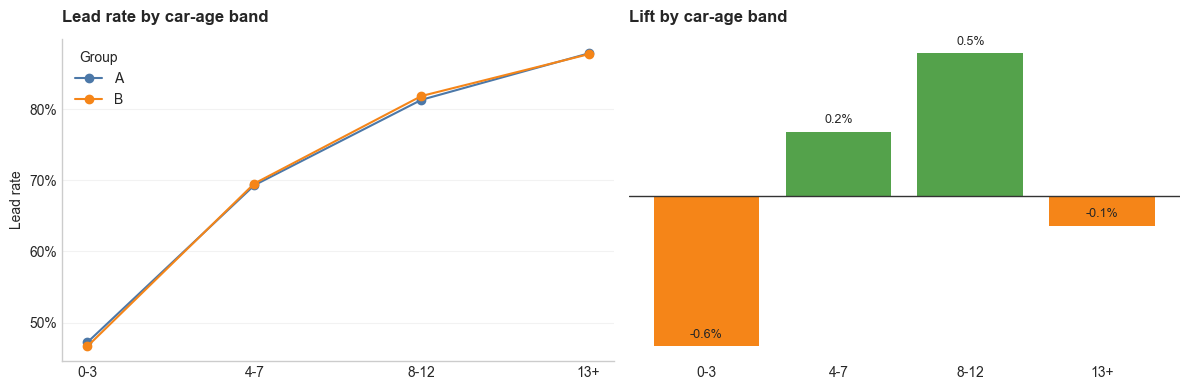

In [22]:
helpers.plot_segment_lift(segmented_data, "car_age_band", "Lead rate by car-age band", "Lift by car-age band")
helpers.plt.show()


Car-age lift is mixed and small, with all differences under 1 percentage point. This could easily be random noise rather than a real age-specific pattern. I include this view because car age is one of the balance gaps between A and B, so it is useful to check whether that imbalance could be driving the overall result. The chart does not suggest a clear age-driven effect, so I would not interpret it as evidence of a meaningful segment pattern.

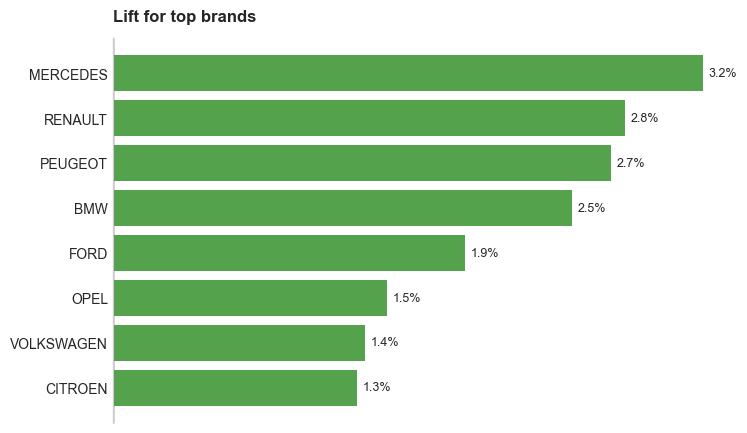

In [23]:
helpers.plot_top_category_lift(ab_data, "brand", "Lift for top brands")
helpers.plt.show()


All shown top brands have positive lift. The strongest lift appears for Mercedes, Renault, Peugeot, and BMW, but these brand cuts are exploratory and should not be treated as separate causal proof.

## 9. Business Conclusion and Recommendation

The observed result is positive: B has more ads with leads and more total leads per ad. For the primary binary KPI, the B-A lead-rate gap is statistically significant (p < 0.001).


In [24]:
helpers.print_business_insights(ab_data)

- Primary Outcome: B has a 2.02% higher share of ads with any lead than A (2.78% relative lift).
- Statistical Inference: At a 5% significance level, the B-A lead-rate gap is statistically significant (p < 0.001). Approximate power for the observed effect is above 99.9%, meaning this sample size would be very likely to detect a true effect of this size.
- Lead Volume: B also has higher average total leads per ad (5.510 vs 5.151).
- Group Balance: The largest average numeric balance gap is price (-10.23% B vs A).
- Interpretation: The result is directionally positive, but should be framed as causal only after confirming the assignment process and exposure logging.


The headline business result is positive for B, but the recommendation should depend on confirming that the test setup is valid. The KPI chart below keeps the final answer anchored in the two headline comparisons: lead rate and average total leads.

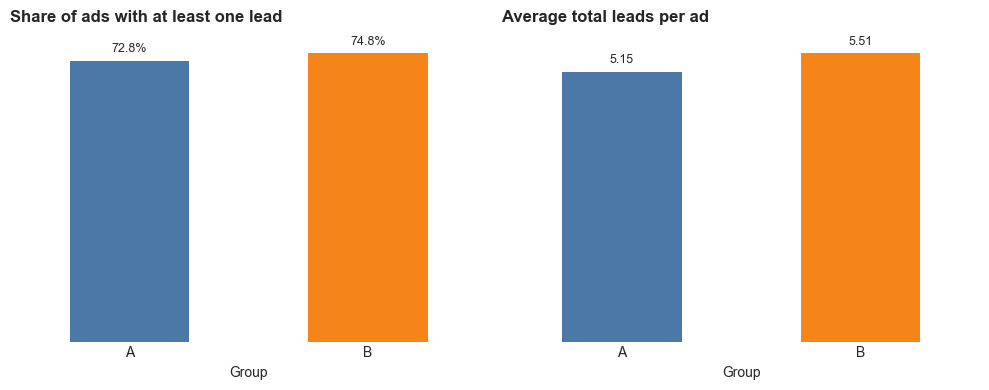

In [25]:
helpers.plot_final_summary(outcomes)
helpers.plt.show()


I would present this as evidence that B performed better, and that the observed lead-rate gap is statistically significant for the primary KPI. I would not present it as final proof that the feature caused the improvement until the experiment setup is validated. The data does not identify the treatment group, and the balance checks show B differs from A on several car dimensions. If A was actually treatment, or if group differences explain the gap, the product conclusion could be different.

Recommended next steps:

1. Confirm randomization, exposure, and which group was treatment.
2. Run a sample-ratio mismatch check for the A/B record counts.
3. Review the 4.7% missing group rows and confirm exclusion rules were defined before reading outcomes.
4. Validate lead logging across A and B.
5. If setup checks pass, consider rollout or controlled ramp.
6. Monitor lead quality and seller/buyer guardrails.
